# **Travaux Pratiques Fusion et Multimodalité**

M2 SD/A2IA

Rodrigo César Coelho Fernandes

## Datasets

In [ ]:
cd drive/MyDrive/RL

/content/drive/MyDrive/RL


In [ ]:
import numpy as np
import pandas as pd
import itertools
import matplotlib.pyplot as plt
from scipy.io import arff
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import accuracy_score

In [ ]:
# Load
data, meta = arff.loadarff("WDBC.arff.txt")
df = pd.DataFrame(data)

if df['Class'].dtype == object:
    df['Class'] = df['Class'].str.decode('utf-8').astype(int)
X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

print(f"Features shape: {X.shape}")
print(f"Labels shape: {y.shape}")

Features shape: (569, 30)
Labels shape: (569,)


In [ ]:
data, meta = arff.loadarff("satimage.arff.txt")
df2 = pd.DataFrame(data)
df2.rename(columns={'class': 'Class'}, inplace=True)
# df['Class'] = df['Class'].astype(bytes)
df2['Class'] = (df2['Class'].replace(b'1.',1)
                          .replace(b'2.',2)
                          .replace(b'3.',3)
                          .replace(b'4.',4)
                          .replace(b'5.',5)
                          .replace(b'7.',6))

X2 = df2.iloc[:, :-1].values
y2 = df2.iloc[:, -1].values

print(f"Features shape: {X2.shape}")
print(f"Labels shape: {y2.shape}")


Features shape: (6430, 36)
Labels shape: (6430,)


/tmp/ipython-input-2139789912.py:10: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .replace(b'7.',6))


In [ ]:
def plot_bagging(n_estimators_list, tree_scores, tree_scores2, knn_scores, knn_scores2):

  fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)

  # ---------- Decision Tree ----------
  ax1 = axes[0]
  ax1.set_title("Decision Tree Bagging")

  color_acc_tree = "tab:green"
  color_oob_tree = "tab:olive"
  color_acc_knn = "tab:blue"
  color_oob_knn = "tab:cyan"

  l1, = ax1.plot(n_estimators_list, tree_scores, marker='o',
                color=color_acc_tree, label="CV Accuracy")
  ax1.set_xlabel("Number of classifiers")
  ax1.set_ylabel("CV Accuracy", color=color_acc_tree)
  ax1.tick_params(axis='y', labelcolor=color_acc_tree)
  ax1.grid(True, alpha=0.3)

  ax1b = ax1.twinx()
  l2, = ax1b.plot(n_estimators_list, tree_scores2, marker='s',
                  linestyle='--', color=color_oob_tree, label="OOB Error")
  ax1b.set_ylabel("OOB Error", color=color_oob_tree)
  ax1b.tick_params(axis='y', labelcolor=color_oob_tree)

  ax1.legend(handles=[l1, l2], loc="best")

  # ---------- kNN ----------
  ax2 = axes[1]
  ax2.set_title("kNN Bagging")

  l3, = ax2.plot(n_estimators_list, knn_scores, marker='o',
                color=color_acc_knn, label="CV Accuracy")
  ax2.set_xlabel("Number of classifiers")
  ax2.set_ylabel("CV Accuracy", color=color_acc_knn)
  ax2.tick_params(axis='y', labelcolor=color_acc_knn)
  ax2.grid(True, alpha=0.3)

  ax2b = ax2.twinx()
  l4, = ax2b.plot(n_estimators_list, knn_scores2, marker='s',
                  linestyle='--', color=color_oob_knn, label="OOB Error")
  ax2b.set_ylabel("OOB Error", color=color_oob_knn)
  ax2b.tick_params(axis='y', labelcolor=color_oob_knn)

  ax2.legend(handles=[l3, l4], loc="best")

  plt.tight_layout()
  plt.show()


def simple_plot(x, y, color, xlabel="x", ylabel="y"):
    """
    Simple plot of y over x.
    """
    plt.figure()
    plt.plot(x, y, marker='o', color=color)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.grid(True, alpha=0.3)
    plt.show()


def plot_double(x, y1, y2, color1, color2, xlabel="x", y1_label="y1", y2_label="y2"):
    """
    Simple plot of two lines (y1, y2) over x.
    """
    plt.figure()
    plt.plot(x, y1, marker='o', color=color1, label=y1_label)
    plt.plot(x, y2, marker='s', color=color2, label=y2_label)
    plt.xlabel(xlabel)
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()




## **1- Bagging**

### Code

In [ ]:
class Bagging:
    def __init__(self, base_estimator="tree", n_estimators=10, knn_k=5, random_state=None):
        self.base_estimator = base_estimator
        self.n_estimators = n_estimators
        self.knn_k = knn_k
        self.random_state = random_state
        self.models = []
        self.oob_indices_ = []

    def _create_model(self, seed):
        if self.base_estimator == "tree":
            return DecisionTreeClassifier(max_depth=1, random_state=seed)
        elif self.base_estimator == "knn":
            return KNeighborsClassifier(
                n_neighbors=self.knn_k,
                algorithm="brute",
                n_jobs=1
            )

    def fit(self, X, y):
        if self.random_state is not None:
            np.random.seed(self.random_state)

        self.models = []
        self.oob_indices_ = []
        n_samples = X.shape[0]

        for i in range(self.n_estimators):
            # Bootstrap sampling
            indices = np.random.choice(n_samples, n_samples, replace=True)
            X_boot = X[indices]
            y_boot = y[indices]

            # Store OOB indices
            oob_indices = np.setdiff1d(np.arange(n_samples), np.unique(indices))

            model = self._create_model(seed=i)
            model.fit(X_boot, y_boot)
            self.models.append(model)
            self.oob_indices_.append(oob_indices)

    def predict(self, X):
        predictions = np.array([model.predict(X) for model in self.models])
        return np.apply_along_axis(
            lambda x: np.bincount(x).argmax(),
            axis=0,
            arr=predictions
        )

    def OutOfBagError(self, X, y):
        """Calculate OOB error correctly"""
        n_samples = X.shape[0]
        oob_predictions = [[] for _ in range(n_samples)]

        # For each model, get predictions for its OOB samples
        for i in range(self.n_estimators):
            model = self.models[i]
            oob_idx = self.oob_indices_[i]

            if len(oob_idx) > 0:
                X_oob = X[oob_idx]
                preds = model.predict(X_oob)

                # Store predictions for each OOB sample
                for idx, pred in zip(oob_idx, preds):
                    oob_predictions[idx].append(pred)

        # For samples that were OOB at least once, get majority vote
        y_pred_oob = np.zeros(n_samples, dtype=int)
        votes_available = np.zeros(n_samples, dtype=bool)

        for i in range(n_samples):
            if len(oob_predictions[i]) > 0:
                y_pred_oob[i] = np.bincount(oob_predictions[i]).argmax()
                votes_available[i] = True

        # Calculate error only on samples with OOB predictions
        mask = votes_available
        if np.sum(mask) == 0:
            return 0  # No OOB samples

        return 1 - accuracy_score(y[mask], y_pred_oob[mask])


In [ ]:
def cv_optimal_n_estimators(X, y, base_estimator, n_estimators_list,max_depth=1, knn_k=5):
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    mean_accuracies = []
    mean_oob_errors = []
    std_accuracies = []
    std_oob_errors = []

    for n_estimators in n_estimators_list:
        fold_accuracies = []
        fold_oob = []

        for train_idx, val_idx in skf.split(X, y):
            X_train, X_val = X[train_idx], X[val_idx]
            y_train, y_val = y[train_idx], y[val_idx]

            # Create model with appropriate parameters
            model = Bagging(
                base_estimator=base_estimator,
                n_estimators=n_estimators,
                knn_k=knn_k,
                random_state=42
            )

            # Fit on training fold only
            model.fit(X_train, y_train)

            # Calculate OOB error on training data
            oob = model.OutOfBagError(X_train, y_train)
            fold_oob.append(oob)

            # Predict on validation fold
            y_pred = model.predict(X_val)
            fold_accuracies.append(accuracy_score(y_val, y_pred))

        mean_accuracies.append(np.mean(fold_accuracies))
        mean_oob_errors.append(np.mean(fold_oob))
        std_accuracies.append(np.std(fold_accuracies))
        std_oob_errors.append(np.std(fold_oob))

    best_index_acc = np.argmax(mean_accuracies)
    best_index_oob = np.argmin(mean_oob_errors)  # Fixed: using mean_oob_errors

    return (n_estimators_list[best_index_acc], mean_accuracies,
            n_estimators_list[best_index_oob], mean_oob_errors,
            std_accuracies, std_oob_errors)

### WDBC

In [ ]:
# nb classifiers
n_estimators_list = [1, 5, 10, 20, 30, 50, 100, 150, 200]
# n_estimators_list = [5]

# # ----- Decision Tree -----
best_n_tree, tree_scores, best_n_tree2, tree_scores2, std_accuracies, std_oob_errors = cv_optimal_n_estimators(
    X, y,
    base_estimator="tree",
    n_estimators_list=n_estimators_list,
    max_depth=1
)

print("Decision Tree Bagging")
for n, acc, oob, stdacc, stdoob in zip(n_estimators_list, tree_scores, tree_scores2, std_accuracies, std_oob_errors):
    print(f"n_estimators={n:2d} | OOB error={oob:.4f}±{stdoob:.4f} | CV accuracy={acc:.4f}±{stdacc:.4f}")

print(f"Optimal nb classifiers (Acc): {best_n_tree}")
print(f"Optimal nb classifiers (OOB): {best_n_tree2}")
print()

# ----- knn -----
best_n_knn, knn_scores, best_n_knn2, knn_scores2, std_accuracies, std_oob_errors = cv_optimal_n_estimators(
    X, y,
    base_estimator="knn",
    n_estimators_list=n_estimators_list,
    knn_k=5
)

print("kNN Bagging")
for n, acc, oob, stdacc, stdoob in zip(n_estimators_list, knn_scores, knn_scores2, std_accuracies, std_oob_errors):
    print(f"n_estimators={n:2d} | OOB error={oob:.4f}±{stdoob:.4f} | CV accuracy={acc:.4f}±{stdacc:.4f}")

print(f"Optimal nb classifiers (Acc): {best_n_knn}")
print(f"Optimal nb classifiers (OOB): {best_n_knn2}")


Decision Tree Bagging
n_estimators= 1 | OOB error=0.0942±0.0202 | CV accuracy=0.9016±0.0325
n_estimators= 5 | OOB error=0.0971±0.0042 | CV accuracy=0.9069±0.0301
n_estimators=10 | OOB error=0.0920±0.0086 | CV accuracy=0.9051±0.0315
n_estimators=20 | OOB error=0.0892±0.0097 | CV accuracy=0.9086±0.0286
n_estimators=30 | OOB error=0.0861±0.0102 | CV accuracy=0.9104±0.0273
n_estimators=50 | OOB error=0.0839±0.0081 | CV accuracy=0.9157±0.0251
n_estimators=100 | OOB error=0.0865±0.0098 | CV accuracy=0.9227±0.0256
n_estimators=150 | OOB error=0.0870±0.0141 | CV accuracy=0.9192±0.0256
n_estimators=200 | OOB error=0.0861±0.0148 | CV accuracy=0.9175±0.0257
Optimal nb classifiers (Acc): 100
Optimal nb classifiers (OOB): 50

kNN Bagging
n_estimators= 1 | OOB error=0.0975±0.0178 | CV accuracy=0.9174±0.0274
n_estimators= 5 | OOB error=0.0720±0.0108 | CV accuracy=0.9245±0.0257
n_estimators=10 | OOB error=0.0673±0.0092 | CV accuracy=0.9280±0.0256
n_estimators=20 | OOB error=0.0707±0.0093 | CV accuracy

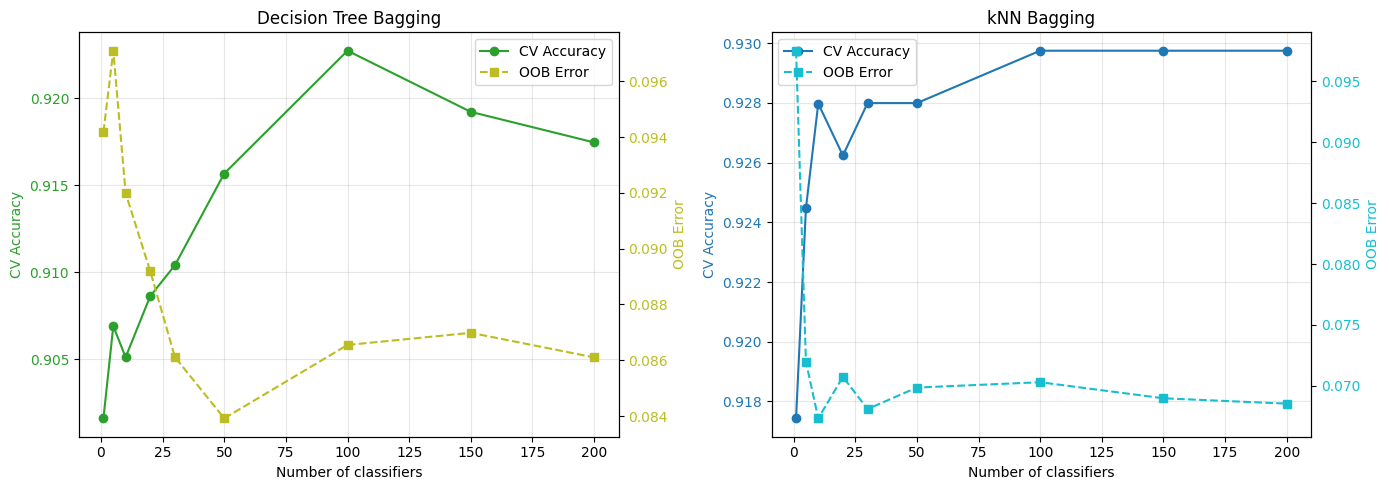

In [ ]:
plot_bagging(n_estimators_list, tree_scores, tree_scores2, knn_scores, knn_scores2)

We can see that the OOB error and the accuracy behave in an oposite way as the number of classifiers increases, the OOB error decreases and acc increases. But they don't seem to agree on the optimal number of classifiers, since the nb that provide the best value for those two metrics is not the same. **THIS HAPPENS BECAUSE**...



### Satimage

In [ ]:
# nb classifiers
n_estimators_list = [1, 5, 10, 20, 30, 50, 100, 150, 200]
# n_estimators_list = [5]

# # ----- Decision Tree -----
best_n_tree, tree_scores, best_n_tree2, tree_scores2, std_accuracies, std_oob_errors = cv_optimal_n_estimators(
    X2, y2,
    base_estimator="tree",
    n_estimators_list=n_estimators_list,
    max_depth=1
)

print("Decision Tree Bagging")
for n, acc, oob, stdacc, stdoob in zip(n_estimators_list, tree_scores, tree_scores2, std_accuracies, std_oob_errors):
    print(f"n_estimators={n:2d} | OOB error={oob:.4f}±{stdoob:.4f} | CV accuracy={acc:.4f}±{stdacc:.4f}")

print(f"Optimal nb classifiers (Acc): {best_n_tree}")
print(f"Optimal nb classifiers (OOB): {best_n_tree2}")
print()

# ----- knn -----
best_n_knn, knn_scores, best_n_knn2, knn_scores2, std_accuracies, std_oob_errors = cv_optimal_n_estimators(
    X2, y2,
    base_estimator="knn",
    n_estimators_list=n_estimators_list,
    knn_k=5
)

print("kNN Bagging")
for n, acc, oob, stdacc, stdoob in zip(n_estimators_list, knn_scores, knn_scores2, std_accuracies, std_oob_errors):
    print(f"n_estimators={n:2d} | OOB error={oob:.4f}±{stdoob:.4f} | CV accuracy={acc:.4f}±{stdacc:.4f}")

print(f"Optimal nb classifiers (Acc): {best_n_knn}")
print(f"Optimal nb classifiers (OOB): {best_n_knn2}")


Decision Tree Bagging
n_estimators= 1 | OOB error=0.5751±0.0057 | CV accuracy=0.4275±0.0035
n_estimators= 5 | OOB error=0.5745±0.0032 | CV accuracy=0.4288±0.0041
n_estimators=10 | OOB error=0.5730±0.0050 | CV accuracy=0.4300±0.0043
n_estimators=20 | OOB error=0.5729±0.0029 | CV accuracy=0.4288±0.0041
n_estimators=30 | OOB error=0.5717±0.0022 | CV accuracy=0.4286±0.0044
n_estimators=50 | OOB error=0.5712±0.0023 | CV accuracy=0.4300±0.0026
n_estimators=100 | OOB error=0.5712±0.0028 | CV accuracy=0.4300±0.0026
n_estimators=150 | OOB error=0.5713±0.0028 | CV accuracy=0.4300±0.0026
n_estimators=200 | OOB error=0.5710±0.0027 | CV accuracy=0.4300±0.0026
Optimal nb classifiers (Acc): 10
Optimal nb classifiers (OOB): 200

kNN Bagging
n_estimators= 1 | OOB error=0.1081±0.0071 | CV accuracy=0.8955±0.0029
n_estimators= 5 | OOB error=0.1036±0.0032 | CV accuracy=0.9072±0.0097
n_estimators=10 | OOB error=0.1017±0.0006 | CV accuracy=0.9048±0.0069
n_estimators=20 | OOB error=0.0958±0.0015 | CV accuracy

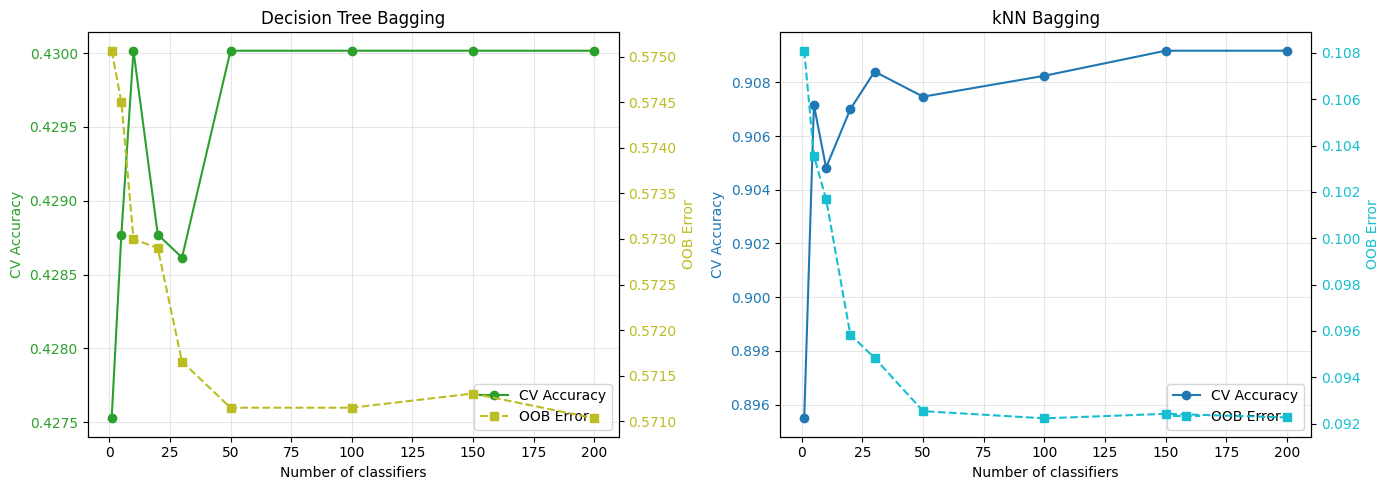

In [ ]:
plot_bagging(n_estimators_list, tree_scores, tree_scores2, knn_scores, knn_scores2)

tree é ruim porque é simples demais para esse exemplo. knn é bom, mas é lento e atinge limite de performance com n_estimators grande

## **2- Boosting**

### Code

In [ ]:
# import numpy as np
# from sklearn.tree import DecisionTreeClassifier
# from sklearn.datasets import make_classification
# from sklearn.model_selection import train_test_split
# from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score, roc_auc_score

In [ ]:
class AdaBoost:
    def __init__(self, base_estimator="tree", n_estimators=50, max_depth=1, knn_k=5):
        self.n_estimators = n_estimators
        self.alphas = []
        self.models = []
        self.base_estimator=base_estimator
        self.max_depth=max_depth
        self.knn_k=knn_k

    def _create_model(self, seed):
        if self.base_estimator == "tree":
            return DecisionTreeClassifier(max_depth=self.max_depth, random_state=seed)
        elif self.base_estimator == "knn":
            return KNeighborsClassifier(
                        n_neighbors=self.knn_k,
                        algorithm="brute",
                        n_jobs=1
                    )

    def fit(self, X, y):
        n_samples, n_features = X.shape

        # Convert y to {-1, +1} for AdaBoost math to work correctly
        self.classes_ = np.unique(y)

        # Map classes to {-1, +1}
        self.class_map_ = {self.classes_[0]: -1, self.classes_[1]: 1}
        y_transformed = np.array([self.class_map_[label] for label in y])

        w = np.ones(n_samples) / n_samples

        for _ in range(self.n_estimators):
            # print(w[:9])
            # model = DecisionTreeClassifier(max_depth=1)
            model = self._create_model(seed=42)
            model.fit(X, y, sample_weight=w)
            predictions = model.predict(X)

            pred_transformed = np.array([self.class_map_[p] for p in predictions])
            incorrect = (pred_transformed != y_transformed)
            err = np.sum(w * incorrect) / np.sum(w)
            err = np.clip(err, 1e-10, 1 - 1e-10)

            alpha = 0.5 * np.log((1 - err) / err)

            self.models.append(model)
            self.alphas.append(alpha)

            w *= np.exp(-alpha * y_transformed * pred_transformed)
            w /= np.sum(w)

    def predict(self, X):
        # Initialize with zeros
        strong_preds = np.zeros(X.shape[0])

        for model, alpha in zip(self.models, self.alphas):
            predictions = model.predict(X)
            # Transform predictions to {-1, +1}
            pred_transformed = np.array([self.class_map_[p] for p in predictions])
            strong_preds += alpha * pred_transformed

        # Convert back to original labels
        # If strong_preds > 0, predict class_1, else class_0
        pred_labels = np.where(strong_preds >= 0,
                               self.classes_[1],
                               self.classes_[0])
        return pred_labels



### WDBC

In [ ]:
n_estimators_list = [1, 5, 10, 20, 30, 50, 100, 150, 200, 250, 300, 350, 400]
# n_estimators_list = [1,5]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# # ----- Decision Tree -----
accs = []

for n in n_estimators_list:
  adaboost = AdaBoost(n_estimators=n, base_estimator="tree", max_depth=1)
  adaboost.fit(X_train, y_train)

  predictions = adaboost.predict(X_test)
  acc = accuracy_score(y_test, predictions)
  print(f"n_estimators = {n:2d} | Accuracy = {acc:.4f}")

  accs = np.append(accs, acc)

best_index = np.argmax(accs)
print(f"Optimal nb classifiers (Acc): {n_estimators_list[best_index]}")


n_estimators= 1 | Accuracy=0.8947
n_estimators= 5 | Accuracy=0.9766
n_estimators=10 | Accuracy=0.9766
n_estimators=20 | Accuracy=0.9591
n_estimators=30 | Accuracy=0.9649
n_estimators=50 | Accuracy=0.9708
n_estimators=100 | Accuracy=0.9708
n_estimators=150 | Accuracy=0.9766
n_estimators=200 | Accuracy=0.9825
n_estimators=250 | Accuracy=0.9708
n_estimators=300 | Accuracy=0.9766
n_estimators=350 | Accuracy=0.9883
n_estimators=400 | Accuracy=0.9883
Optimal nb classifiers (Acc): 350


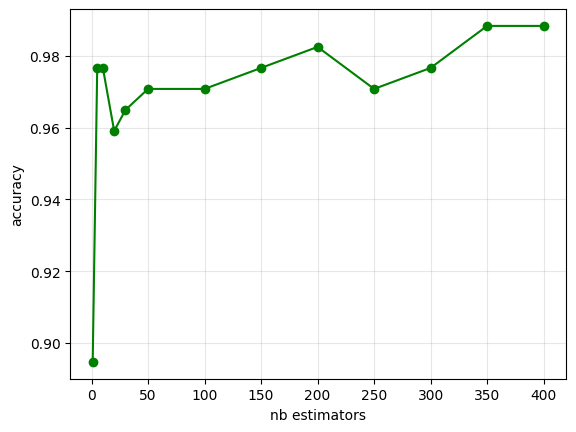

In [ ]:
simple_plot(n_estimators_list, accs, "green", "nb estimators", "accuracy")

## **3- Random Subspace Method**

### Code

In [ ]:
class RandomSubspace:
    def __init__(self, base_estimator="tree", n_estimators=10, max_features="sqrt",max_depth=1, knn_k=5, random_state=None):
        self.base_estimator = base_estimator
        self.n_estimators = n_estimators
        self.max_features = max_features
        self.max_depth = max_depth
        self.knn_k = knn_k
        self.random_state = random_state
        self.models = []
        self.feature_indices_ = []

    def _create_model(self, seed):
        if self.base_estimator == "tree":
            return DecisionTreeClassifier(max_depth=self.max_depth, random_state=seed)
        elif self.base_estimator == "knn":
            return KNeighborsClassifier(
                n_neighbors=self.knn_k,
                algorithm="brute",
                n_jobs=1
            )

    def _num_features(self, n_features):
        if self.max_features == "sqrt":
            return int(np.sqrt(n_features))
        elif self.max_features == "log2":
            return int(np.log2(n_features))
        elif isinstance(self.max_features, float):
            return int(self.max_features * n_features)
        else:
            return int(self.max_features)

    def fit(self, X, y):
        np.random.seed(self.random_state)
        self.models = []
        self.feature_indices_ = []

        n_samples, n_features = X.shape
        n_sub_features = self._num_features(n_features)

        for i in range(self.n_estimators):
            feat_idx = np.random.choice(
                n_features,
                n_sub_features,
                replace=False
            )

            model = self._create_model(seed=i)
            model.fit(X[:, feat_idx], y)

            self.models.append(model)
            self.feature_indices_.append(feat_idx)

    def predict(self, X):
        predictions = []

        for model, feat_idx in zip(self.models, self.feature_indices_):
            preds = model.predict(X[:, feat_idx])
            predictions.append(preds)

        predictions = np.array(predictions)

        return np.apply_along_axis(
            lambda x: np.bincount(x).argmax(),
            axis=0,
            arr=predictions
        )


In [ ]:
def cv_optimal_n_estimators_rsm(
    X,
    y,
    base_estimator,
    n_estimators_list,
    max_features="sqrt",
    knn_k=5,
    max_depth=1
):
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    mean_accuracies = []
    std_accuracies = []

    for n_estimators in n_estimators_list:
        fold_accuracies = []

        for train_idx, val_idx in skf.split(X, y):
            X_train, X_val = X[train_idx], X[val_idx]
            y_train, y_val = y[train_idx], y[val_idx]

            model = RandomSubspace(
                base_estimator=base_estimator,
                n_estimators=n_estimators,
                max_features=max_features,
                knn_k=knn_k,
                random_state=42
            )

            model.fit(X_train, y_train)
            y_pred = model.predict(X_val)
            fold_accuracies.append(accuracy_score(y_val, y_pred))

        mean_accuracies.append(np.mean(fold_accuracies))
        std_accuracies.append(np.std(fold_accuracies))


    best_index = np.argmax(mean_accuracies)
    return n_estimators_list[best_index], mean_accuracies,std_accuracies


### WDBC

In [ ]:
n_estimators_list = [1, 5, 10, 20, 30, 50, 100, 150, 200]

# ----- Decision Tree -----
best_n_tree, tree_scores, stdacc = cv_optimal_n_estimators_rsm(
    X, y,
    base_estimator="tree",
    n_estimators_list=n_estimators_list,
    max_features="sqrt",
    max_depth=1
)

print("Decision Tree – Random Subspace")
for n, acc, std in zip(n_estimators_list, tree_scores, stdacc):
    print(f"n_estimators={n:3d} | CV accuracy={acc:.4f} ± {std:.4f}")

print(f"Optimal nb classifiers: {best_n_tree}")
print()

# ----- kNN -----
best_n_knn, knn_scores, stdacc = cv_optimal_n_estimators_rsm(
    X, y,
    base_estimator="knn",
    n_estimators_list=n_estimators_list,
    max_features="sqrt",
    knn_k=5
)

print("kNN – Random Subspace")
for n, acc, std in zip(n_estimators_list, knn_scores, stdacc):
    print(f"n_estimators={n:3d} | CV accuracy={acc:.4f} ± {std:.4f}")

print(f"Optimal nb classifiers: {best_n_knn}")


Decision Tree – Random Subspace
n_estimators=  1 | CV accuracy=0.9068 ± 0.0181
n_estimators=  5 | CV accuracy=0.8928 ± 0.0210
n_estimators= 10 | CV accuracy=0.9139 ± 0.0170
n_estimators= 20 | CV accuracy=0.9209 ± 0.0298
n_estimators= 30 | CV accuracy=0.9174 ± 0.0302
n_estimators= 50 | CV accuracy=0.9227 ± 0.0325
n_estimators=100 | CV accuracy=0.9192 ± 0.0279
n_estimators=150 | CV accuracy=0.9139 ± 0.0262
n_estimators=200 | CV accuracy=0.9174 ± 0.0286
Optimal nb classifiers: 50

kNN – Random Subspace
n_estimators=  1 | CV accuracy=0.9087 ± 0.0210
n_estimators=  5 | CV accuracy=0.8999 ± 0.0296
n_estimators= 10 | CV accuracy=0.8998 ± 0.0204
n_estimators= 20 | CV accuracy=0.9209 ± 0.0156
n_estimators= 30 | CV accuracy=0.9209 ± 0.0214
n_estimators= 50 | CV accuracy=0.9262 ± 0.0196
n_estimators=100 | CV accuracy=0.9420 ± 0.0233
n_estimators=150 | CV accuracy=0.9420 ± 0.0233
n_estimators=200 | CV accuracy=0.9420 ± 0.0233
Optimal nb classifiers: 100


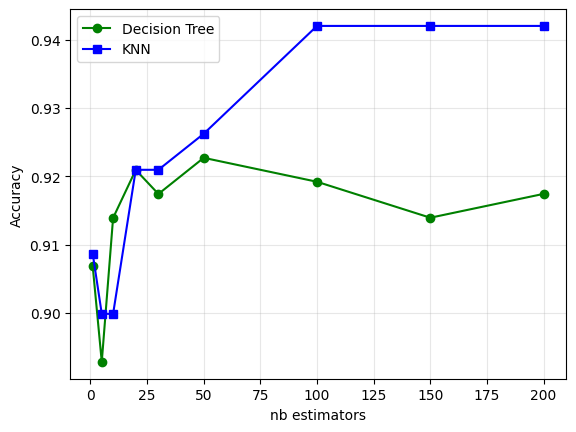

In [ ]:
plot_double(n_estimators_list, tree_scores, knn_scores, "green", "blue", "nb estimators", "Decision Tree", "KNN")

### Satimage

In [ ]:
n_estimators_list = [1, 5, 10, 20, 30, 50, 100, 150, 200]

# ----- Decision Tree -----
best_n_tree, tree_scores, stdacc = cv_optimal_n_estimators_rsm(
    X2, y2,
    base_estimator="tree",
    n_estimators_list=n_estimators_list,
    max_features="sqrt",
    max_depth=1
)

print("Decision Tree – Random Subspace")
for n, acc, std in zip(n_estimators_list, tree_scores, stdacc):
    print(f"n_estimators={n:3d} | CV accuracy={acc:.4f} ± {std:.4f}")

print(f"Optimal nb classifiers: {best_n_tree}")
print()

# ----- kNN -----
best_n_knn, knn_scores, stdacc = cv_optimal_n_estimators_rsm(
    X2, y2,
    base_estimator="knn",
    n_estimators_list=n_estimators_list,
    max_features="sqrt",
    knn_k=5
)

print("kNN – Random Subspace")
for n, acc, std in zip(n_estimators_list, knn_scores, stdacc):
    print(f"n_estimators={n:3d} | CV accuracy={acc:.4f} ± {std:.4f}")

print(f"Optimal nb classifiers: {best_n_knn}")


Decision Tree – Random Subspace
n_estimators=  1 | CV accuracy=0.4269 ± 0.0039
n_estimators=  5 | CV accuracy=0.4272 ± 0.0041
n_estimators= 10 | CV accuracy=0.4170 ± 0.0040
n_estimators= 20 | CV accuracy=0.4278 ± 0.0036
n_estimators= 30 | CV accuracy=0.4244 ± 0.0054
n_estimators= 50 | CV accuracy=0.4272 ± 0.0044
n_estimators=100 | CV accuracy=0.4258 ± 0.0042
n_estimators=150 | CV accuracy=0.4267 ± 0.0042
n_estimators=200 | CV accuracy=0.4289 ± 0.0034
Optimal nb classifiers: 200

kNN – Random Subspace
n_estimators=  1 | CV accuracy=0.8454 ± 0.0071
n_estimators=  5 | CV accuracy=0.8854 ± 0.0061
n_estimators= 10 | CV accuracy=0.8908 ± 0.0047
n_estimators= 20 | CV accuracy=0.8972 ± 0.0062
n_estimators= 30 | CV accuracy=0.8963 ± 0.0062
n_estimators= 50 | CV accuracy=0.8977 ± 0.0071
n_estimators=100 | CV accuracy=0.8988 ± 0.0061
n_estimators=150 | CV accuracy=0.8988 ± 0.0066
n_estimators=200 | CV accuracy=0.8992 ± 0.0073
Optimal nb classifiers: 200


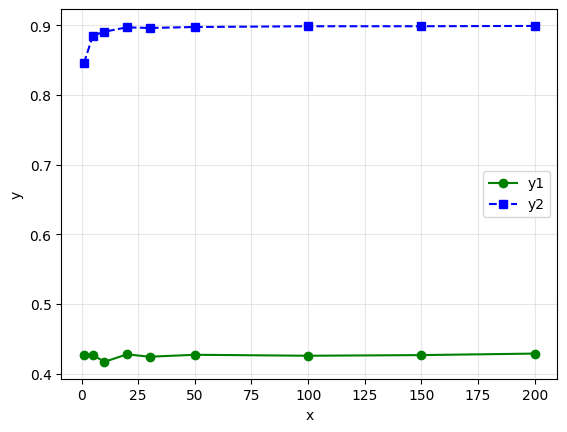

In [ ]:
plot_double(n_estimators_list, tree_scores, knn_scores, "green", "blue")

## **4- ECOC**

### Code

In [ ]:
def exhaustive_code_matrix(classes):
    """
    Generate exhaustive ECOC code matrix.
    Rows: classes
    Columns: binary classifiers
    """
    K = len(classes)
    codes = []

    # Generate all binary vectors of length K
    for bits in itertools.product([0, 1], repeat=K):
        if sum(bits) == 0 or sum(bits) == K:
            continue  # trivial partitions
        if bits[0] == 0:
            continue  # avoid complements
        codes.append(bits)

    return np.array(codes).T  # shape (K, L)


In [ ]:
class ECOC:
    def __init__(self, random_state=None, base_estimator="tree", max_depth=1, knn_k=5, n_estimators=200):
        self.random_state = random_state
        self.models = []
        self.code_matrix_ = None
        self.classes_ = None
        self.base_estimator = base_estimator
        self.max_depth = max_depth
        self.knn_k = knn_k
        self.n_estimators=n_estimators

    def _create_model(self, seed):
        if self.base_estimator == "tree":
            return DecisionTreeClassifier(max_depth=self.max_depth, random_state=seed)
        elif self.base_estimator == "knn":
            return KNeighborsClassifier(
                n_neighbors=self.knn_k,
                algorithm="brute",
                n_jobs=1)
        elif self.base_estimator == "adaboost":
                return AdaBoost(n_estimators=self.n_estimators, base_estimator="tree", max_depth=1)


    def fit(self, X, y):
        self.classes_ = np.unique(y)
        K = len(self.classes_)

        # Build exhaustive code matrix
        self.code_matrix_ = exhaustive_code_matrix(self.classes_)
        L = self.code_matrix_.shape[1]

        self.models = []

        for j in range(L):
            column = self.code_matrix_[:, j]

            # Map multiclass labels to binary labels for this classifier
            y_binary = np.array([
                column[np.where(self.classes_ == label)[0][0]]
                for label in y
            ])

            # clf = DecisionTreeClassifier(
            #     max_depth=1,
            #     random_state=None if self.random_state is None else self.random_state + j
            # )
            model = self._create_model(seed=self.random_state)
            model.fit(X, y_binary)
            self.models.append(model)

    def predict(self, X):
        # Collect predictions from all binary classifiers
        binary_predictions = np.array([
            model.predict(X) for model in self.models
        ]).T  # shape (n_samples, L)

        predictions = []

        for sample_code in binary_predictions:
            # Hamming distance to each class codeword
            distances = np.sum(
                sample_code != self.code_matrix_,
                axis=1
            )
            predictions.append(self.classes_[np.argmin(distances)])

        return np.array(predictions)


### Satimage

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X2, y2, test_size=0.3, random_state=42)


# ----- Decision Tree -----
model = ECOC(random_state=42, base_estimator="tree", max_depth=1)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)

print("Tree – accuracy:", acc)


# ----- kNN -----
model = ECOC(random_state=42, base_estimator="knn", knn_k=5)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print("kNN – accuracy:", acc)


# ----- kNN -----
model = ECOC(random_state=42, base_estimator="adaboost", n_estimators=200)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print("Adaboost – accuracy:", acc)


Tree – accuracy: 0.7558320373250389
kNN – accuracy: 0.9051321928460342
Adaboost – accuracy: 0.8833592534992224


In [ ]:
max_depth_values = [1, 2, 3, 4, 5, 7, 10, None]

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

tree_scores = {}

for depth in max_depth_values:
    fold_accuracies = []

    for train_idx, val_idx in cv.split(X2, y2):
        X_train, X_val = X2[train_idx], X2[val_idx]
        y_train, y_val = y2[train_idx], y2[val_idx]

        model = ECOC(
            random_state=42,
            base_estimator="tree",
            max_depth=depth
        )

        model.fit(X_train, y_train)
        y_pred = model.predict(X_val)

        fold_accuracies.append(accuracy_score(y_val, y_pred))

    tree_scores[depth] = np.mean(fold_accuracies)

best_depth = max(tree_scores, key=tree_scores.get)

print("Decision Tree CV results:")
for d, acc in tree_scores.items():
    print(f"max_depth={d}: mean accuracy={acc:.4f}")

print("\nBest max_depth:", best_depth)


Decision Tree CV results:
max_depth=1: mean accuracy=0.7361
max_depth=2: mean accuracy=0.7961
max_depth=3: mean accuracy=0.8327
max_depth=4: mean accuracy=0.8551
max_depth=5: mean accuracy=0.8664
max_depth=7: mean accuracy=0.8832
max_depth=10: mean accuracy=0.8961
max_depth=None: mean accuracy=0.9050

Best max_depth: None


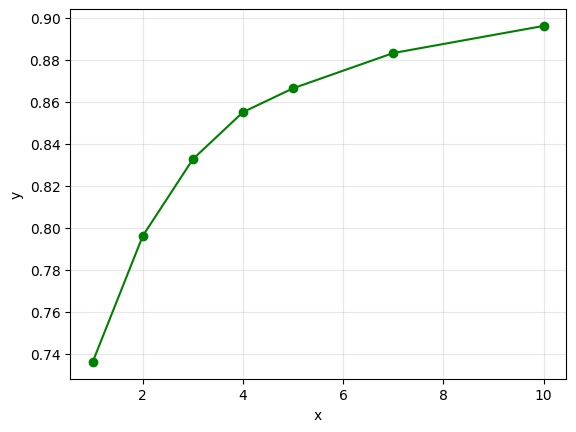

In [ ]:
simple_plot(max_depth_values, list(tree_scores.values()), "green")

In [ ]:
knn_k_values = [1, 3, 5, 7, 9, 11, 15]

knn_scores = {}

for k in knn_k_values:
    fold_accuracies = []

    for train_idx, val_idx in cv.split(X2, y2):
        X_train, X_val = X2[train_idx], X2[val_idx]
        y_train, y_val = y2[train_idx], y2[val_idx]

        model = ECOC(
            random_state=42,
            base_estimator="knn",
            knn_k=k
        )

        model.fit(X_train, y_train)
        y_pred = model.predict(X_val)

        fold_accuracies.append(accuracy_score(y_val, y_pred))

    knn_scores[k] = np.mean(fold_accuracies)

best_k = max(knn_scores, key=knn_scores.get)

print("kNN CV results:")
for k, acc in knn_scores.items():
    print(f"knn_k={k}: mean accuracy={acc:.4f}")

print("\nBest knn_k:", best_k)


kNN CV results:
knn_k=1: mean accuracy=0.9054
knn_k=3: mean accuracy=0.9076
knn_k=5: mean accuracy=0.9053
knn_k=7: mean accuracy=0.9028
knn_k=9: mean accuracy=0.9017
knn_k=11: mean accuracy=0.8978
knn_k=15: mean accuracy=0.8950

Best knn_k: 3


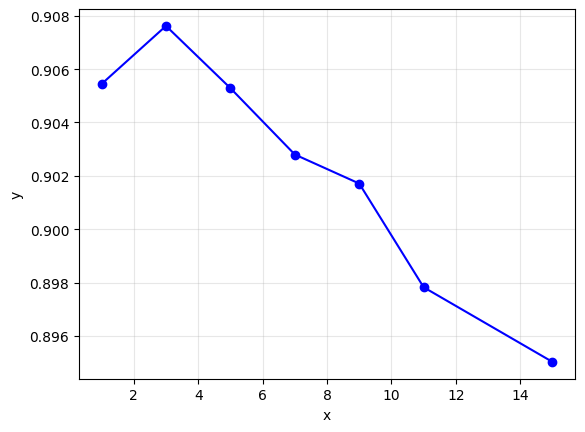

In [ ]:
simple_plot(knn_k_values, list(knn_scores.values()), "blue")

### ECOC + Adaboost

In [ ]:
n_estimators_list = [1, 5, 10, 20, 30, 50, 100, 150, 200, 250, 300, 350, 400]

adaboost_scores = {}

for n_estimators in n_estimators_list:
    fold_accuracies = []

    for train_idx, val_idx in cv.split(X2, y2):
        X_train, X_val = X2[train_idx], X2[val_idx]
        y_train, y_val = y2[train_idx], y2[val_idx]

        model = ECOC(
            random_state=42,
            base_estimator="adaboost",
            n_estimators=n_estimators
        )

        model.fit(X_train, y_train)
        y_pred = model.predict(X_val)

        fold_accuracies.append(accuracy_score(y_val, y_pred))

    adaboost_scores[n_estimators] = np.mean(fold_accuracies)

best_n = max(adaboost_scores, key=adaboost_scores.get)

print("adaboost CV results:")
for n_estimators, acc in adaboost_scores.items():
    print(f"n_estimators={n_estimators}: mean accuracy={acc:.4f}")

print("\nBest n_estimators:", best_n)


adaboost CV results:
n_estimators=1: mean accuracy=0.7361
n_estimators=5: mean accuracy=0.8118
n_estimators=10: mean accuracy=0.8370
n_estimators=20: mean accuracy=0.8493
n_estimators=30: mean accuracy=0.8560
n_estimators=50: mean accuracy=0.8630
n_estimators=100: mean accuracy=0.8711
n_estimators=150: mean accuracy=0.8743
n_estimators=200: mean accuracy=0.8774
n_estimators=250: mean accuracy=0.8782
n_estimators=300: mean accuracy=0.8807
n_estimators=350: mean accuracy=0.8823
n_estimators=400: mean accuracy=0.8826

Best n_estimators: 400


### ???

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X2, y2, test_size=0.3, random_state=42, stratify=y2
)

# Best Tree
tree_model = ECOC(
    random_state=42,
    base_estimator="tree",
    max_depth=best_depth
)
tree_model.fit(X_train, y_train)
tree_acc = accuracy_score(y_test, tree_model.predict(X_test))

# Best kNN
knn_model = ECOC(
    random_state=42,
    base_estimator="knn",
    knn_k=best_k
)
knn_model.fit(X_train, y_train)
knn_acc = accuracy_score(y_test, knn_model.predict(X_test))

# Best adaboost
adaboost_model = ECOC(
    random_state=42,
    base_estimator="adaboost",
    n_estimators=best_n
)
adaboost_model.fit(X_train, y_train)
adaboost_acc = accuracy_score(y_test, adaboost_model.predict(X_test))

print("Final Tree accuracy:", tree_acc)
print("Final kNN accuracy:", knn_acc)
print("Final adaboost accuracy:", adaboost_acc)


Final Tree accuracy: 0.9082426127527217
Final kNN accuracy: 0.9020217729393468
Final adaboost accuracy: 0.8921721099015034


# =========================================

In [ ]:
import numpy as np
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score

# Assuming your ensemble models are imported or defined in this scope
# from your_models import Bagging, AdaBoost, RandomSubspace, ECOC

def search_dataset1(X, y, max_depth_values=None, knn_k_values=None, n_estimators_list=None):
    """
    Perform hyperparameter search for Dataset 1 with 5-fold CV.
    Models available: Bagging, AdaBoost, RandomSubspace
    """
    # Default hyperparameter values if not provided
    if max_depth_values is None:
        max_depth_values = [1, 2, 5, 10, None]
    if knn_k_values is None:
        knn_k_values = [1, 3, 5, 7]
    if n_estimators_list is None:
        n_estimators_list = [50, 100, 150, 200]

    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    results = []

    # ========== BAGGING with tree ==========
    print("Searching Bagging with Decision Tree...")
    for n_estimators in n_estimators_list:
        for max_depth in max_depth_values:
            fold_scores = []
            for train_idx, val_idx in kf.split(X):
                X_train, X_val = X[train_idx], X[val_idx]
                y_train, y_val = y[train_idx], y[val_idx]

                model = Bagging(X_train, y_train,
                              base_estimator="tree",
                              n_estimators=n_estimators,
                              random_state=42,
                              max_depth=max_depth,
                              knn_k=None)
                model.fit(X_train, y_train)
                y_pred = model.predict(X_val)
                fold_scores.append(accuracy_score(y_val, y_pred))

            avg_score = np.mean(fold_scores)
            results.append({
                'model': 'Bagging_tree',
                'n_estimators': n_estimators,
                'max_depth': max_depth,
                'knn_k': None,
                'avg_score': avg_score
            })

    # ========== BAGGING with knn ==========
    print("Searching Bagging with KNN...")
    for n_estimators in n_estimators_list:
        for knn_k in knn_k_values:
            fold_scores = []
            for train_idx, val_idx in kf.split(X):
                X_train, X_val = X[train_idx], X[val_idx]
                y_train, y_val = y[train_idx], y[val_idx]

                model = Bagging(X_train, y_train,
                              base_estimator="knn",
                              n_estimators=n_estimators,
                              random_state=42,
                              max_depth=None,
                              knn_k=knn_k)
                model.fit(X_train, y_train)
                y_pred = model.predict(X_val)
                fold_scores.append(accuracy_score(y_val, y_pred))

            avg_score = np.mean(fold_scores)
            results.append({
                'model': 'Bagging_knn',
                'n_estimators': n_estimators,
                'max_depth': None,
                'knn_k': knn_k,
                'avg_score': avg_score
            })

    # ========== ADABOOST (only tree, only dataset 1) ==========
    print("Searching AdaBoost...")
    for n_estimators in n_estimators_list:
        # AdaBoost with tree (max_depth fixed at 1 as per specification)
        fold_scores = []
        for train_idx, val_idx in kf.split(X):
            X_train, X_val = X[train_idx], X[val_idx]
            y_train, y_val = y[train_idx], y[val_idx]

            model = AdaBoost(n_estimators=n_estimators,
                           base_estimator="tree",
                           max_depth=1)
            model.fit(X_train, y_train)
            y_pred = model.predict(X_val)
            fold_scores.append(accuracy_score(y_val, y_pred))

        avg_score = np.mean(fold_scores)
        results.append({
            'model': 'AdaBoost',
            'n_estimators': n_estimators,
            'max_depth': 1,  # Fixed
            'knn_k': None,
            'avg_score': avg_score
        })

    # ========== RANDOM SUBSPACE with tree ==========
    print("Searching RandomSubspace with Decision Tree...")
    max_features = 0.5  # You might want to parameterize this too
    for n_estimators in n_estimators_list:
        for max_depth in max_depth_values:
            fold_scores = []
            for train_idx, val_idx in kf.split(X):
                X_train, X_val = X[train_idx], X[val_idx]
                y_train, y_val = y[train_idx], y[val_idx]

                model = RandomSubspace(
                    base_estimator="tree",
                    n_estimators=n_estimators,
                    max_features=max_features,
                    knn_k=None,
                    random_state=42,
                    max_depth=max_depth
                )
                # Assuming your constructor takes max_depth parameter
                # If not, you might need to modify the model initialization
                model.fit(X_train, y_train)
                y_pred = model.predict(X_val)
                fold_scores.append(accuracy_score(y_val, y_pred))

            avg_score = np.mean(fold_scores)
            results.append({
                'model': 'RandomSubspace_tree',
                'n_estimators': n_estimators,
                'max_depth': max_depth,
                'knn_k': None,
                'avg_score': avg_score
            })

    # ========== RANDOM SUBSPACE with knn ==========
    print("Searching RandomSubspace with KNN...")
    for n_estimators in n_estimators_list:
        for knn_k in knn_k_values:
            fold_scores = []
            for train_idx, val_idx in kf.split(X):
                X_train, X_val = X[train_idx], X[val_idx]
                y_train, y_val = y[train_idx], y[val_idx]

                model = RandomSubspace(
                    base_estimator="knn",
                    n_estimators=n_estimators,
                    max_features=max_features,
                    knn_k=knn_k,
                    random_state=42
                )
                model.fit(X_train, y_train)
                y_pred = model.predict(X_val)
                fold_scores.append(accuracy_score(y_val, y_pred))

            avg_score = np.mean(fold_scores)
            results.append({
                'model': 'RandomSubspace_knn',
                'n_estimators': n_estimators,
                'max_depth': None,
                'knn_k': knn_k,
                'avg_score': avg_score
            })

    # Find best model
    best_result = max(results, key=lambda x: x['avg_score'])

    print("\n=== DATASET 1 SEARCH COMPLETE ===")
    print(f"Best model: {best_result['model']}")
    print(f"Best parameters: n_estimators={best_result['n_estimators']}, "
          f"max_depth={best_result['max_depth']}, knn_k={best_result['knn_k']}")
    print(f"Best CV score: {best_result['avg_score']:.4f}")

    return results, best_result


def search_dataset2(X2, y2, max_depth_values=None, knn_k_values=None, n_estimators_list=None):
    """
    Perform hyperparameter search for Dataset 2 with 5-fold CV.
    Models available: Bagging, RandomSubspace, ECOC
    """
    # Default hyperparameter values if not provided
    if max_depth_values is None:
        max_depth_values = [1, 2, 5, 10, None]
    if knn_k_values is None:
        knn_k_values = [1, 3, 5, 7]
    if n_estimators_list is None:
        n_estimators_list = [50, 100, 150, 200]

    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    results = []

    # ========== BAGGING with tree ==========
    print("Searching Bagging with Decision Tree...")
    for n_estimators in n_estimators_list:
        for max_depth in max_depth_values:
            fold_scores = []
            for train_idx, val_idx in kf.split(X2):
                X_train, X_val = X2[train_idx], X2[val_idx]
                y_train, y_val = y2[train_idx], y2[val_idx]

                model = Bagging(X_train, y_train,
                              base_estimator="tree",
                              n_estimators=n_estimators,
                              random_state=42,
                              max_depth=max_depth,
                              knn_k=None)
                model.fit(X_train, y_train)
                y_pred = model.predict(X_val)
                fold_scores.append(accuracy_score(y_val, y_pred))

            avg_score = np.mean(fold_scores)
            results.append({
                'model': 'Bagging_tree',
                'n_estimators': n_estimators,
                'max_depth': max_depth,
                'knn_k': None,
                'avg_score': avg_score
            })

    # ========== BAGGING with knn ==========
    print("Searching Bagging with KNN...")
    for n_estimators in n_estimators_list:
        for knn_k in knn_k_values:
            fold_scores = []
            for train_idx, val_idx in kf.split(X2):
                X_train, X_val = X2[train_idx], X2[val_idx]
                y_train, y_val = y2[train_idx], y2[val_idx]

                model = Bagging(X_train, y_train,
                              base_estimator="knn",
                              n_estimators=n_estimators,
                              random_state=42,
                              max_depth=None,
                              knn_k=knn_k)
                model.fit(X_train, y_train)
                y_pred = model.predict(X_val)
                fold_scores.append(accuracy_score(y_val, y_pred))

            avg_score = np.mean(fold_scores)
            results.append({
                'model': 'Bagging_knn',
                'n_estimators': n_estimators,
                'max_depth': None,
                'knn_k': knn_k,
                'avg_score': avg_score
            })

    # ========== RANDOM SUBSPACE with tree ==========
    print("Searching RandomSubspace with Decision Tree...")
    max_features = 0.5  # You might want to parameterize this too
    for n_estimators in n_estimators_list:
        for max_depth in max_depth_values:
            fold_scores = []
            for train_idx, val_idx in kf.split(X2):
                X_train, X_val = X2[train_idx], X2[val_idx]
                y_train, y_val = y2[train_idx], y2[val_idx]

                model = RandomSubspace(
                    base_estimator="tree",
                    n_estimators=n_estimators,
                    max_features=max_features,
                    knn_k=None,
                    max_depth=max_depth,
                    random_state=42
                )
                model.fit(X_train, y_train)
                y_pred = model.predict(X_val)
                fold_scores.append(accuracy_score(y_val, y_pred))

            avg_score = np.mean(fold_scores)
            results.append({
                'model': 'RandomSubspace_tree',
                'n_estimators': n_estimators,
                'max_depth': max_depth,
                'knn_k': None,
                'avg_score': avg_score
            })

    # ========== RANDOM SUBSPACE with knn ==========
    print("Searching RandomSubspace with KNN...")
    for n_estimators in n_estimators_list:
        for knn_k in knn_k_values:
            fold_scores = []
            for train_idx, val_idx in kf.split(X2):
                X_train, X_val = X2[train_idx], X2[val_idx]
                y_train, y_val = y2[train_idx], y2[val_idx]

                model = RandomSubspace(
                    base_estimator="knn",
                    n_estimators=n_estimators,
                    max_features=max_features,
                    knn_k=knn_k,
                    random_state=42
                )
                model.fit(X_train, y_train)
                y_pred = model.predict(X_val)
                fold_scores.append(accuracy_score(y_val, y_pred))

            avg_score = np.mean(fold_scores)
            results.append({
                'model': 'RandomSubspace_knn',
                'n_estimators': n_estimators,
                'max_depth': None,
                'knn_k': knn_k,
                'avg_score': avg_score
            })

    # ========== ECOC (only dataset 2, both base_estimators) ==========
    # ECOC with tree
    print("Searching ECOC with Decision Tree...")
    for max_depth in max_depth_values:
        fold_scores = []
        for train_idx, val_idx in kf.split(X2):
            X_train, X_val = X2[train_idx], X2[val_idx]
            y_train, y_val = y2[train_idx], y2[val_idx]

            model = ECOC(
                random_state=42,
                base_estimator="tree",
                max_depth=max_depth,
                knn_k=None
            )
            model.fit(X_train, y_train)
            y_pred = model.predict(X_val)
            fold_scores.append(accuracy_score(y_val, y_pred))

        avg_score = np.mean(fold_scores)
        results.append({
            'model': 'ECOC_tree',
            'n_estimators': None,  # ECOC doesn't have n_estimators
            'max_depth': max_depth,
            'knn_k': None,
            'avg_score': avg_score
        })

    # ECOC with knn
    print("Searching ECOC with KNN...")
    for knn_k in knn_k_values:
        fold_scores = []
        for train_idx, val_idx in kf.split(X2):
            X_train, X_val = X2[train_idx], X2[val_idx]
            y_train, y_val = y2[train_idx], y2[val_idx]

            model = ECOC(
                random_state=42,
                base_estimator="knn",
                max_depth=None,
                knn_k=knn_k
            )
            model.fit(X_train, y_train)
            y_pred = model.predict(X_val)
            fold_scores.append(accuracy_score(y_val, y_pred))

        avg_score = np.mean(fold_scores)
        results.append({
            'model': 'ECOC_knn',
            'n_estimators': None,  # ECOC doesn't have n_estimators
            'max_depth': None,
            'knn_k': knn_k,
            'avg_score': avg_score
        })

    # Find best model
    best_result = max(results, key=lambda x: x['avg_score'])

    print("\n=== DATASET 2 SEARCH COMPLETE ===")
    print(f"Best model: {best_result['model']}")
    print(f"Best parameters: n_estimators={best_result['n_estimators']}, "
          f"max_depth={best_result['max_depth']}, knn_k={best_result['knn_k']}")
    print(f"Best CV score: {best_result['avg_score']:.4f}")

    return results, best_result


# Helper function to visualize results
def print_top_results(results, n_top=10):
    """Print top n results from hyperparameter search."""
    sorted_results = sorted(results, key=lambda x: x['avg_score'], reverse=True)

    print(f"\nTop {n_top} results:")
    print("=" * 80)
    for i, result in enumerate(sorted_results[:n_top]):
        print(f"{i+1}. Model: {result['model']}")
        print(f"   Score: {result['avg_score']:.4f}")
        print(f"   Params: n_estimators={result['n_estimators']}, "
              f"max_depth={result['max_depth']}, knn_k={result['knn_k']}")
        print("-" * 80)


# Usage example:
if __name__ == "__main__":
    # Assuming you have your datasets loaded
    # X, y = ... (dataset 1)
    # X2, y2 = ... (dataset 2)

    # Search for best model on dataset 1
    print("=" * 60)
    print("SEARCHING FOR BEST MODEL ON DATASET 1")
    print("=" * 60)
    results1, best1 = search_dataset1(X, y)
    print_top_results(results1, n_top=5)

    # Search for best model on dataset 2
    print("\n" + "=" * 60)
    print("SEARCHING FOR BEST MODEL ON DATASET 2")
    print("=" * 60)
    results2, best2 = search_dataset2(X2, y2)
    print_top_results(results2, n_top=5)

SEARCHING FOR BEST MODEL ON DATASET 1
Searching Bagging with Decision Tree...


TypeError: Bagging.__init__() got multiple values for argument 'base_estimator'